# Parte 3: Entrenamiendo y ejecución de modelo por el Método 1

En éste código se va a entrenar el modelo usando los datos originales ya filtrados en la parte 2 y mediante capas convolucionales, de pooling, flatten y red neuronal artificial simple.

In [1]:
#Importación de las librerías necesarias
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import Callback, EarlyStopping
import gc
import os
import multiprocessing

Leemos el archivo de Películas con imagen, el cual obtuvimos en la parte 2 del preprocesamiento.

In [2]:
with open('C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Películas con imagen.csv', encoding='utf-8') as f:
        movies = pd.read_csv(f, sep=',')

In [3]:
movies.sample(5)

,index,imdbID,Genre,Poster,Action,Adventure,Animation,Comedy,Crime,Drama,Family,Fantasy,Horror,Music,Mystery,Romance,Sci-Fi,Sport,Thriller,Existe
25132,25305,tt0235023,"Drama,Romance",https://m.media-amazon.com/images/M/MV5BMjE5Mm...,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
14948,15037,tt0105121,"Comedy,Horror,Mystery",https://m.media-amazon.com/images/M/MV5BYjViYT...,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,1
40863,41180,tt8017140,Thriller,https://m.media-amazon.com/images/M/MV5BYmE2MT...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
44798,45148,tt7021560,Thriller,https://m.media-amazon.com/images/M/MV5BZWRiY2...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
23011,23164,tt0185936,"Action,Comedy,Horror",https://m.media-amazon.com/images/M/MV5BNGI3MD...,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [5]:
print(movies.shape)

(47756, 20)


Vamos a buscar el archivo .jpg de cada película para ingresarla a una lista de imágenes.

In [6]:
#Definimos el array donde se van a ir guardando las imágenes
imagenes = []
for i in tqdm(range(movies.shape[0])):
    archivo = movies['imdbID'][i]
    path = "C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Posters/" + archivo + '.jpg'
    #Leemos la imagen
    imagen = image.load_img(path, target_size=(250, 250))
    imagen = image.img_to_array(imagen)
    imagen = imagen / 255
    #Agregamos la imagen a la lista de imágenes
    imagenes.append(imagen)

100%|██████████| 47756/47756 [07:40<00:00, 103.66it/s]


Las imágenes las ingresamos en el array que conforma las x, que será la variable dependiente. Este será un array de 4 dimensiones.

In [7]:
x = np.array(imagenes)

In [8]:
x.shape

(47756, 250, 250, 3)

In [9]:
#Borramos el array de imágenes para liberar espacio en RAM
del imagenes

Validamos que el índice corresponda a la imagen y su asignación.

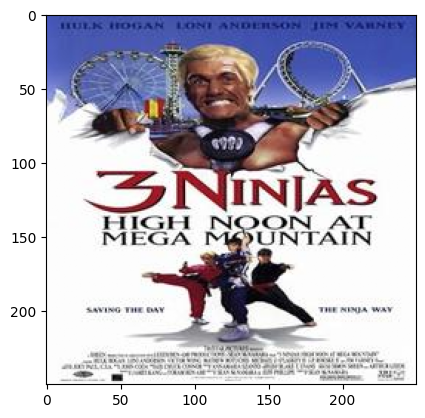

In [10]:
plt.imshow(x[18720])

In [11]:
movies.iloc[18720]

index                                                    18838
imdbID                                               tt0118539
Genre                                  Action,Adventure,Comedy
Poster       https://m.media-amazon.com/images/M/MV5BY2IzOT...
Action                                                       1
Adventure                                                    1
Animation                                                    0
Comedy                                                       1
Crime                                                        0
Drama                                                        0
Family                                                       0
Fantasy                                                      0
Horror                                                       0
Music                                                        0
Mystery                                                      0
Romance                                                

Una vez validado, se inserta en la variable y lo correspondiente a solo las columnas de los géneros, que son 15. Eliminamos las columnas que no nos sirven.

In [12]:
#Ahora con las y
y = movies.drop(columns = ['imdbID', 'Genre', 'Poster', 'Existe', 'index'])
y = y.to_numpy()
print(y.shape), print(type(y))

(47756, 15)
<class 'numpy.ndarray'>


(None, None)

# Entrenamiento del modelo

Realizamos el split de entrenamiento y prueba con un 80-20.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20)

In [14]:
#Borramos la x para liberar espacio en RAM
del x

In [15]:
X_train[0].shape

(250, 250, 3)

Vamos a definir las capas del modelo.

In [16]:
#Modelo secuencial
model = Sequential()

#Primera capa convolucional
model.add(Conv2D(16, (3, 3), activation='relu', input_shape= (250, 250, 3)))
#Primera capa de pooling
model.add(MaxPool2D(2,2))

#Segunda capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu'))
#Segunda capa de pooling
model.add(MaxPool2D(2,2))

#Tercera capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))
#Tercera capa de pooling
model.add(MaxPool2D(2,2))

#Cuarta capa convolucional
model.add(Conv2D(128, (3, 3), activation='relu'))
#Cuarta capa de pooling
model.add(MaxPool2D(2,2))

#Capa de aplanado
model.add(Flatten())

#Primera capa de ANN
model.add(Dense(64, activation='relu'))
#Segunda capa de ANN
model.add(Dense(128, activation='relu'))
#Capa de salida de ANN
model.add(Dense(15, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,492,207 (5.69 MB)

 Trainable params: 1,492,207 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Limpiamos para liberar espacio en RAM
gc.collect()

13

In [19]:
#Se compila
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')

In [20]:
#Se entrena el modelo
history = model.fit(X_train, y_train, batch_size=20, epochs=15, validation_data=(X_test, y_test))

Epoch 1/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 624s 323ms/step - accuracy: 0.2891 - loss: 0.3280 - val_accuracy: 0.3295 - val_loss: 0.3170
Epoch 2/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 520s 272ms/step - accuracy: 0.3233 - loss: 0.3120 - val_accuracy: 0.3448 - val_loss: 0.3084
Epoch 3/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 529s 277ms/step - accuracy: 0.3371 - loss: 0.3055 - val_accuracy: 0.3396 - val_loss: 0.3062
Epoch 4/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 516s 270ms/step - accuracy: 0.3553 - loss: 0.3000 - val_accuracy: 0.3585 - val_loss: 0.3078
Epoch 5/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 512s 268ms/step - accuracy: 0.3793 - loss: 0.2891 - val_accuracy: 0.3414 - val_loss: 0.3091
Epoch 6/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 499s 261ms/step - accuracy: 0.4109 - loss: 0.2719 - val_accuracy: 0.3369 - val_loss: 0.3225
Epoch 7/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 496s 259ms/step - accuracy: 0.4408 - loss: 0.2518 - val_accuracy: 0.3162 - val_loss: 0.3396
Epoch 8/15
1911/1911 ━━━━━━━━━━━━━━━━━━━━ 494s 258ms/step - ac

Una vez entrenado el modelo, vamos a hacer la predición del 20% de prueba.

In [21]:
pred = model.predict(X_test)

299/299 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step


Comparamos los valores de Accuracy y Loss versus Val_Accuracy y Val_loss

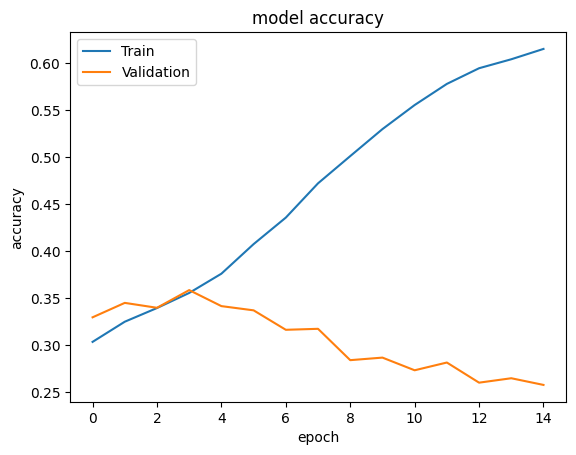

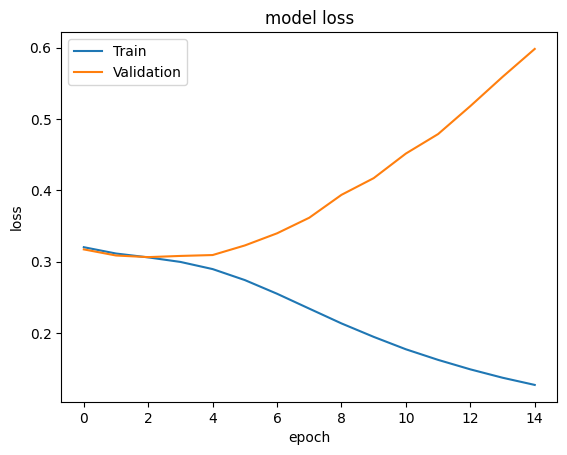

In [23]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Por último, calculamos las métricas para la comparativa.

In [26]:
#Librerías necesarias para la metrica
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss, jaccard_score

In [27]:
#Arriba del 10% de probabilidad, se toma como éxito
umbral = 0.1
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.026381909547738693
Precisión (Precision) - Micro: 0.27428254369470734
Precisión (Precision) - Macro: 0.18835562966174632
Recuperación (Recall) - Micro: 0.500478092131166
Recuperación (Recall) - Macro: 0.3332397995165747
F1-Score - Micro: 0.3543608124253286
F1-Score - Macro: 0.2387541068033698
Pérdida de Hamming (Hamming Loss): 0.22629815745393636
Jaccard Score (Coefficient): 0.2500383759177729


In [28]:
#Arriba del 20% de probabilidad, se toma como éxito
umbral = 0.2
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.04983249581239531
Precisión (Precision) - Micro: 0.30434782608695654
Precisión (Precision) - Macro: 0.20660193830748838
Recuperación (Recall) - Micro: 0.41813375330446034
Recuperación (Recall) - Macro: 0.2672301182465497
F1-Score - Micro: 0.352280535481578
F1-Score - Macro: 0.2304944454662544
Pérdida de Hamming (Hamming Loss): 0.19079424902289224
Jaccard Score (Coefficient): 0.2584631611641662


In [29]:
#Arriba del 30% de probabilidad, se toma como éxito
umbral = 0.3
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.07014237855946398
Precisión (Precision) - Micro: 0.32521879086611005
Precisión (Precision) - Macro: 0.2175225953915392
Recuperación (Recall) - Micro: 0.3636874964846167
Recuperación (Recall) - Macro: 0.2252698299075565
F1-Score - Micro: 0.34337909242983455
F1-Score - Macro: 0.2182846543719084
Pérdida de Hamming (Hamming Loss): 0.17259212730318257
Jaccard Score (Coefficient): 0.25941949329983255


In [30]:
#Arriba del 40% de probabilidad, se toma como éxito
umbral = 0.4
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.08479899497487438
Precisión (Precision) - Micro: 0.34132345029589334
Precisión (Precision) - Macro: 0.22335997373304456
Recuperación (Recall) - Micro: 0.32116541987738345
Recuperación (Recall) - Macro: 0.19347241876090548
F1-Score - Micro: 0.33093775356439087
F1-Score - Macro: 0.20394002669148084
Pérdida de Hamming (Hamming Loss): 0.1611390284757119
Jaccard Score (Coefficient): 0.2549317769402568


In [31]:
#Arriba del 50% de probabilidad, se toma como éxito
umbral = 0.5
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.09212730318257957
Precisión (Precision) - Micro: 0.35496398813726876
Precisión (Precision) - Macro: 0.22951026934583432
Recuperación (Recall) - Micro: 0.2827493109848698
Recuperación (Recall) - Macro: 0.1662605005735434
F1-Score - Micro: 0.3147678532293917
F1-Score - Macro: 0.18896057708131356
Pérdida de Hamming (Hamming Loss): 0.1527568397543272
Jaccard Score (Coefficient): 0.24279569972880274


Definimos el umbral con el F1 más alto e imprimimos un ejemplo aleatorio.

In [42]:
umbral = 0.3
y_pred_binarizado = np.where(pred > umbral, 1, 0)

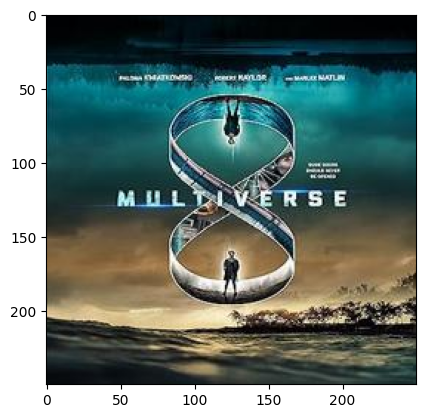

In [39]:
plt.imshow(X_test[1654])

In [40]:
print(y_test[1654])

[0 0 0 0 0 1 0 0 0 0 1 0 1 0 0]


In [43]:
print(y_pred_binarizado[1654])

[0 0 0 0 0 0 0 0 1 1 0 0 0 0 0]
